# Iris Dataset - Exploratory Data Analysis

**AI & ML Internship - Task 1 (optional advanced challenge)**

A second, smaller EDA on the classic **Iris** dataset. The main project of this task is the
*Student Performance Data Explorer* (`student_performance_eda.ipynb`); this notebook applies the same
workflow to a different kind of data: physical measurements of flowers instead of exam scores.

## 1. Introduction
The Iris dataset contains **150 flowers**, 50 from each of three species (*setosa*, *versicolor*,
*virginica*). Four measurements (in cm) were taken for every flower: sepal length, sepal width, petal
length and petal width.

**Questions:**
1. Is the data complete and clean?
2. How are the four measurements distributed?
3. Which measurements are strongly related?
4. Do the species differ in their measurements?
5. Are there outliers?

> No machine-learning model is built here; this is data exploration only.

## 2. Import Libraries

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = Path("../data/iris.csv")
if not DATA_PATH.exists():                      # fallback: notebook started from the project root
    DATA_PATH = Path("data/iris.csv")

PROJECT_ROOT = DATA_PATH.resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
from src import data_analysis as da            # re-use the statistics/outlier helpers from the main project

IMAGES_DIR = PROJECT_ROOT / "images"
da.set_plot_style()

## 3. Load Dataset
The file `data/iris.csv` (source and license: see `data/README.md`) is loaded with pandas.

In [2]:
df = pd.read_csv(DATA_PATH)
FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
print("Loaded:", DATA_PATH)
print("Shape (rows, columns):", df.shape)
df.head(10)

Loaded: ..\data\iris.csv
Shape (rows, columns): (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
df.tail(5)

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


## 4. Dataset Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
print("Measurements (numerical):", FEATURES)
print("Label (categorical)     :", "species")
print()
print("Number of flowers per species:")
df["species"].value_counts()

Measurements (numerical): ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Label (categorical)     : species

Number of flowers per species:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### Observation
The dataset has **150 rows and 5 columns**: four numerical measurement columns (`float64`) and one
categorical column, `species`. The three species are perfectly balanced (50 flowers each).

## 5. Data Quality Analysis

In [6]:
print("Missing values per column:")
display(df.isna().sum().to_frame("missing_count"))
print("Total missing cells:", int(df.isna().sum().sum()))
print()
print("Number of fully duplicated rows:", int(df.duplicated().sum()))
display(df[df.duplicated(keep=False)])

Missing values per column:


,missing_count
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


Total missing cells: 0

Number of fully duplicated rows: 1


,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [7]:
# Basic validity check: measurements must be positive
print("Smallest value of each measurement (cm):")
df[FEATURES].min()

Smallest value of each measurement (cm):


sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64

### Observation and decision
* **Missing values:** none.
* **Duplicates:** exactly **one pair** of identical rows was found (two *virginica* flowers with the
  measurements 5.8, 2.7, 5.1 and 1.9). Unlike in the student dataset, no row is removed here. The
  measurements are only recorded to 0.1 cm, and two *different* flowers can easily have the same
  values, so this is not necessarily a data-entry error. The rows are **kept**.
* **Validity:** all measurements are positive, so there are no impossible values.

## 6. Descriptive Statistics

In [8]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [9]:
# Mean, median, mode, std, min, quartiles, max and skewness in one table
da.descriptive_statistics(df, FEATURES)

,mean,median,mode,std,min,q1,q3,max,skewness
sepal_length,5.843,5.80,5.0,0.828,4.3,5.1,6.4,7.9,0.315
sepal_width,3.057,3.00,3.0,0.436,2.0,2.8,3.3,4.4,0.319
petal_length,3.758,4.35,1.4,1.765,1.0,1.6,5.1,6.9,-0.275
petal_width,1.199,1.30,0.2,0.762,0.1,0.3,1.8,2.5,-0.103


### Observation
* Sepal length averages 5.84 cm and sepal width 3.06 cm; petal length averages 3.76 cm and petal width
  1.20 cm.
* **Petal length varies the most** (standard deviation 1.77 cm) and **sepal width the least**
  (0.44 cm).
* For **petal length** the mean (3.76) is far below the median (4.35) and the mode (1.4) is very small.
  This is unusual for a single variable and suggests that the flowers form more than one group
  (checked in the histograms below).

## 7. Correlation Analysis

In [10]:
corr = da.correlation_matrix(df, FEATURES)
display(corr.round(3))
da.ranked_correlations(corr)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


,variable_1,variable_2,correlation
0,petal_length,petal_width,0.963
1,sepal_length,petal_length,0.872
2,sepal_length,petal_width,0.818
3,sepal_length,sepal_width,-0.118
4,sepal_width,petal_width,-0.366
5,sepal_width,petal_length,-0.428


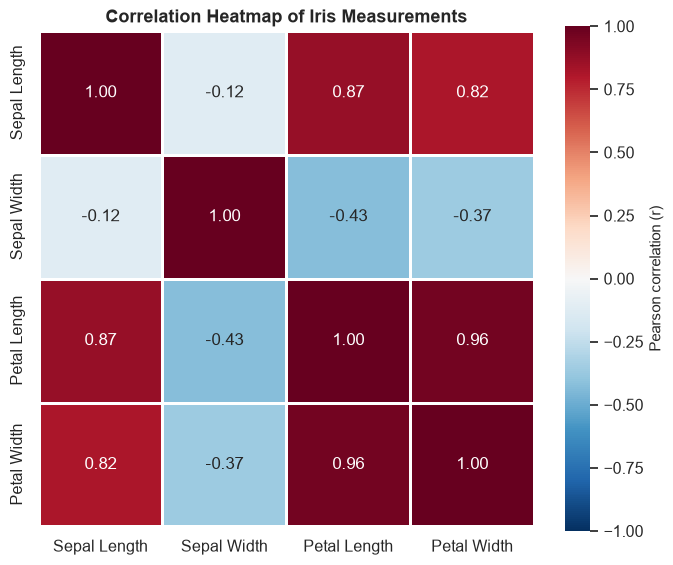

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.8))
labels = [da.nice_name(c) for c in FEATURES]
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, linewidths=0.8,
            xticklabels=labels, yticklabels=labels, cbar_kws={"label": "Pearson correlation (r)"}, ax=ax)
ax.set_title("Correlation Heatmap of Iris Measurements")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "iris_correlation_heatmap.png", bbox_inches="tight", facecolor="white")
plt.show()

### Observation
* **Strongest relationship:** petal length and petal width (**r = 0.963**), followed by sepal length
  and petal length (**r = 0.872**) and sepal length and petal width (**r = 0.818**).
* **Negative relationships:** sepal width is *negatively* correlated with petal length (-0.428) and petal
  width (-0.366), and only weakly with sepal length (-0.118). Sepal width behaves differently from the
  other three measurements.
* As always, correlation does not prove causation. Also, the overall correlations mix all three species
  together; the species comparison below shows why this matters.

## 8. Distributions (Histograms)

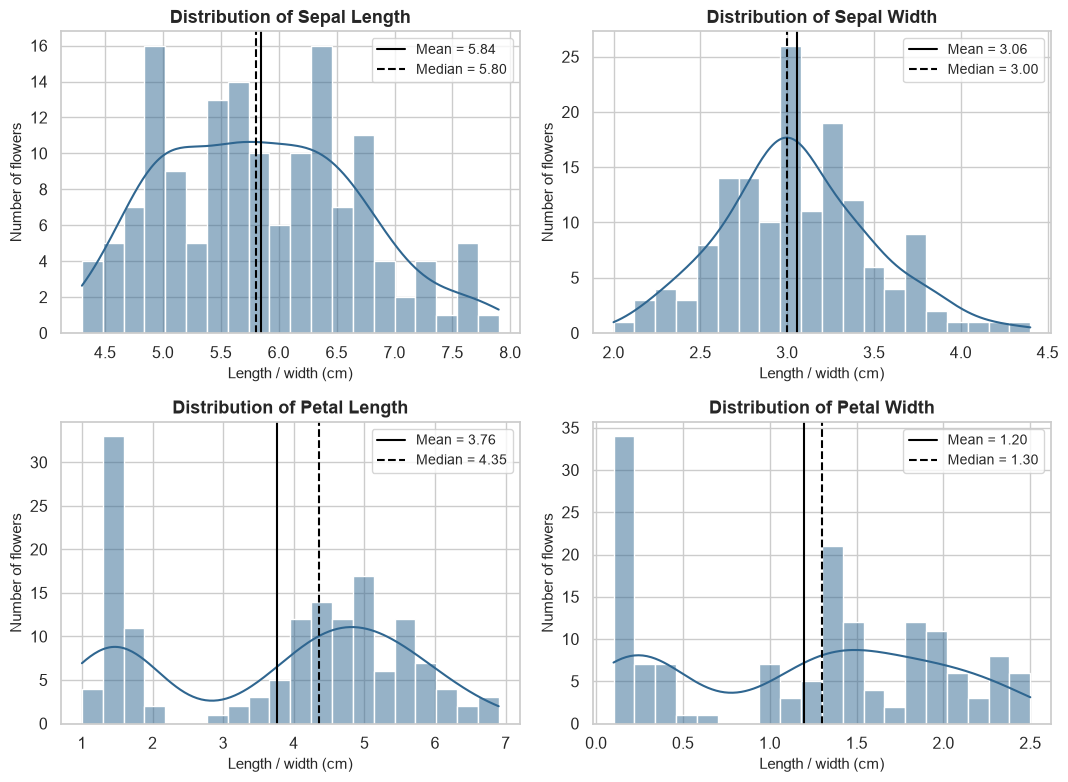

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.histplot(df[col], bins=20, kde=True, color="#2F6690", edgecolor="white", ax=ax)
    ax.axvline(df[col].mean(), color="black", linestyle="-", label=f"Mean = {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color="black", linestyle="--", label=f"Median = {df[col].median():.2f}")
    ax.set_title(f"Distribution of {da.nice_name(col)}")
    ax.set_xlabel("Length / width (cm)")
    ax.set_ylabel("Number of flowers")
    ax.legend()
plt.tight_layout()
fig.savefig(IMAGES_DIR / "iris_histograms.png", bbox_inches="tight", facecolor="white")
plt.show()

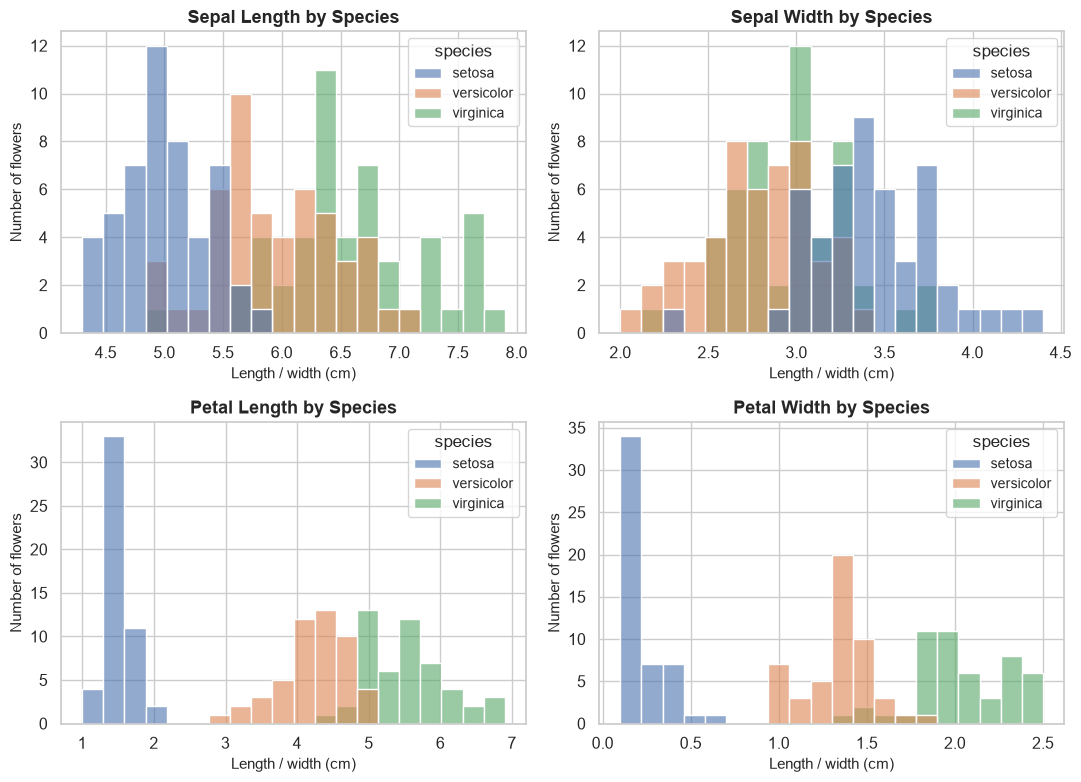

In [13]:
# The same histograms, coloured by species
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.histplot(data=df, x=col, hue="species", bins=20, alpha=0.6, edgecolor="white", ax=ax)
    ax.set_title(f"{da.nice_name(col)} by Species")
    ax.set_xlabel("Length / width (cm)")
    ax.set_ylabel("Number of flowers")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "iris_histograms_by_species.png", bbox_inches="tight", facecolor="white")
plt.show()

### Observation
* **Sepal width** is roughly bell-shaped with a peak near 3.0 cm. **Sepal length** is broad and
  flat-topped with several small peaks between about 4.3 and 7.9 cm, so it does not follow a clear
  bell shape.
* **Petal length and petal width** are clearly *not* bell-shaped: there is a separate cluster of small
  values on the left (petal length about 1-2 cm) and a wider group of larger values on the right. This
  explains the gap between mean and median seen earlier.
* Colouring by species shows the cause: the small-petal cluster consists entirely of *setosa* flowers,
  while *versicolor* and *virginica* occupy the larger values (with some overlap between them).

## 9. Relationships (Scatter Plots)

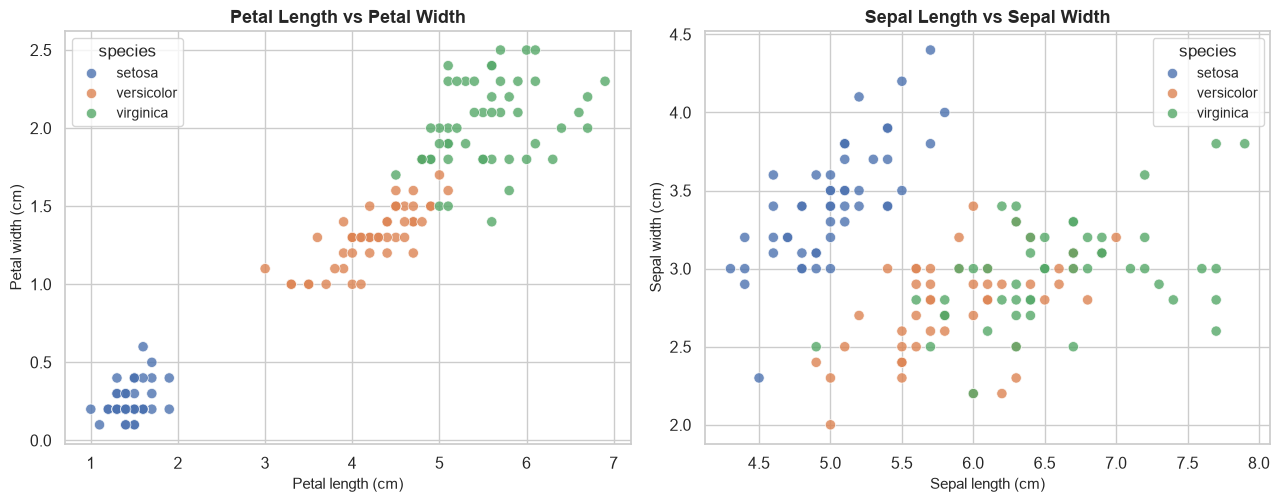

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", s=55, alpha=0.8, ax=axes[0])
axes[0].set_title("Petal Length vs Petal Width")
axes[0].set_xlabel("Petal length (cm)")
axes[0].set_ylabel("Petal width (cm)")

sns.scatterplot(data=df, x="sepal_length", y="sepal_width", hue="species", s=55, alpha=0.8, ax=axes[1])
axes[1].set_title("Sepal Length vs Sepal Width")
axes[1].set_xlabel("Sepal length (cm)")
axes[1].set_ylabel("Sepal width (cm)")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "iris_scatter_plot.png", bbox_inches="tight", facecolor="white")
plt.show()

In [15]:
# Does the strong overall petal correlation also hold inside each species?
print("Correlation of petal length and petal width")
print(f"  all flowers together: {df['petal_length'].corr(df['petal_width']):.3f}")
for species, group in df.groupby("species"):
    print(f"  {species:11s}: {group['petal_length'].corr(group['petal_width']):.3f}")

Correlation of petal length and petal width
  all flowers together: 0.963
  setosa     : 0.332
  versicolor : 0.787
  virginica  : 0.322


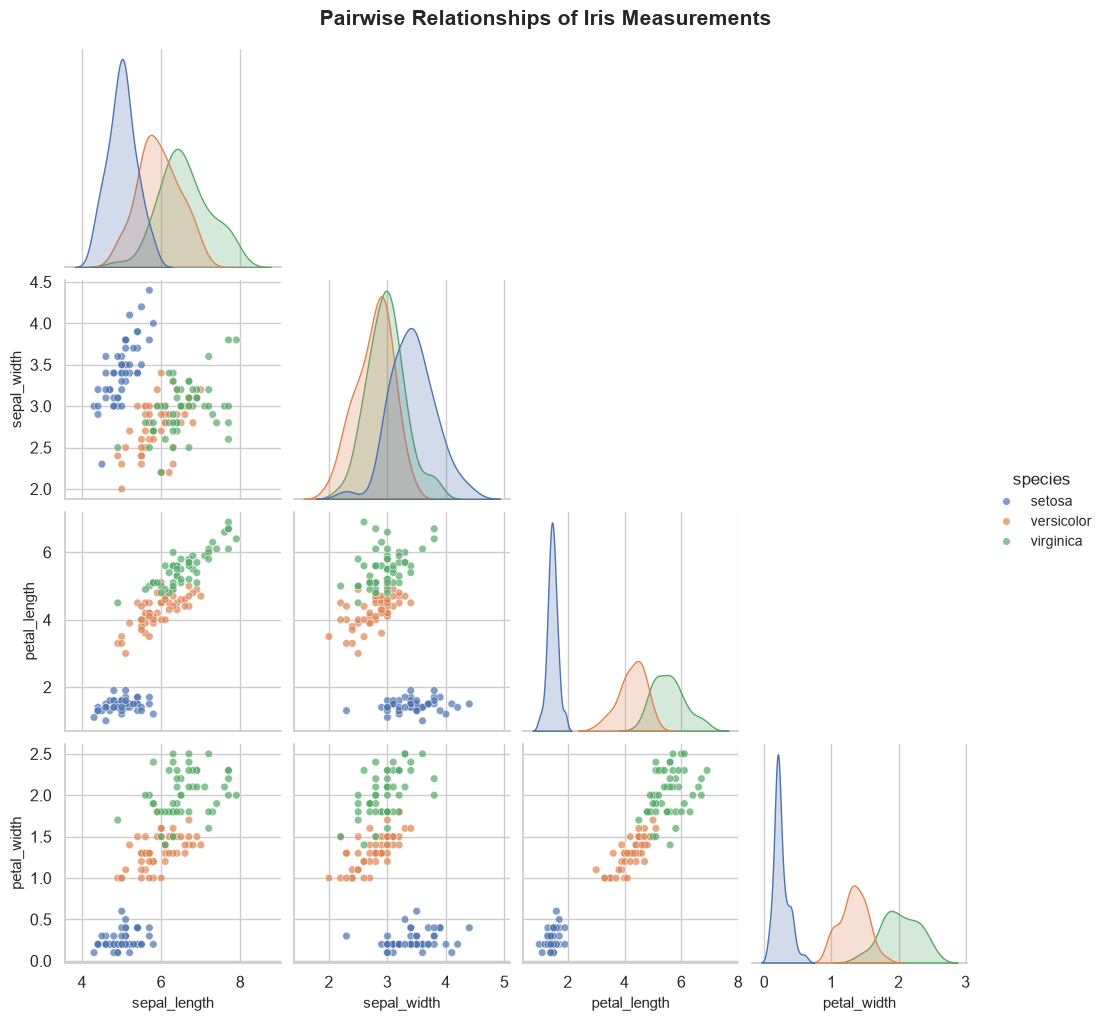

In [16]:
# Overview of all pairs of measurements
pair_grid = sns.pairplot(df, hue="species", corner=True, plot_kws={"alpha": 0.7, "s": 30})
pair_grid.figure.suptitle("Pairwise Relationships of Iris Measurements", y=1.02, fontweight="bold")
pair_grid.figure.savefig(IMAGES_DIR / "iris_pairplot.png", bbox_inches="tight", facecolor="white")
plt.show()

### Observation
* The petal plot shows three groups: **setosa** forms a tight cluster with the smallest petals, and
  **versicolor** and **virginica** follow a rising line, with virginica having the largest petals.
  Setosa is completely separated from the other two species; versicolor and virginica overlap slightly.
* In the sepal plot the species overlap much more, so sepal measurements separate the species
  less clearly than petal measurements.
* The overall petal correlation of 0.963 is **stronger than the correlation inside each species**
  (setosa 0.332, versicolor 0.787, virginica 0.322). A large part of the strong overall correlation comes
  from the *differences between species*, not only from a relationship inside each species. This is
  a good example of why a correlation should always be interpreted together with the group structure.

## 10. Outlier Analysis
The IQR rule is used again: values below `Q1 - 1.5 x IQR` or above `Q3 + 1.5 x IQR` are potential outliers.

In [17]:
da.iqr_outlier_summary(df, FEATURES)

,column,lower_fence,upper_fence,n_outliers,percent_of_rows,lowest_value,highest_value
0,sepal_length,3.15,8.35,0,0.00,NaN,NaN
1,sepal_width,2.05,4.05,4,2.67,2.0,4.4
2,petal_length,-3.65,10.35,0,0.00,NaN,NaN
3,petal_width,-1.95,4.05,0,0.00,NaN,NaN


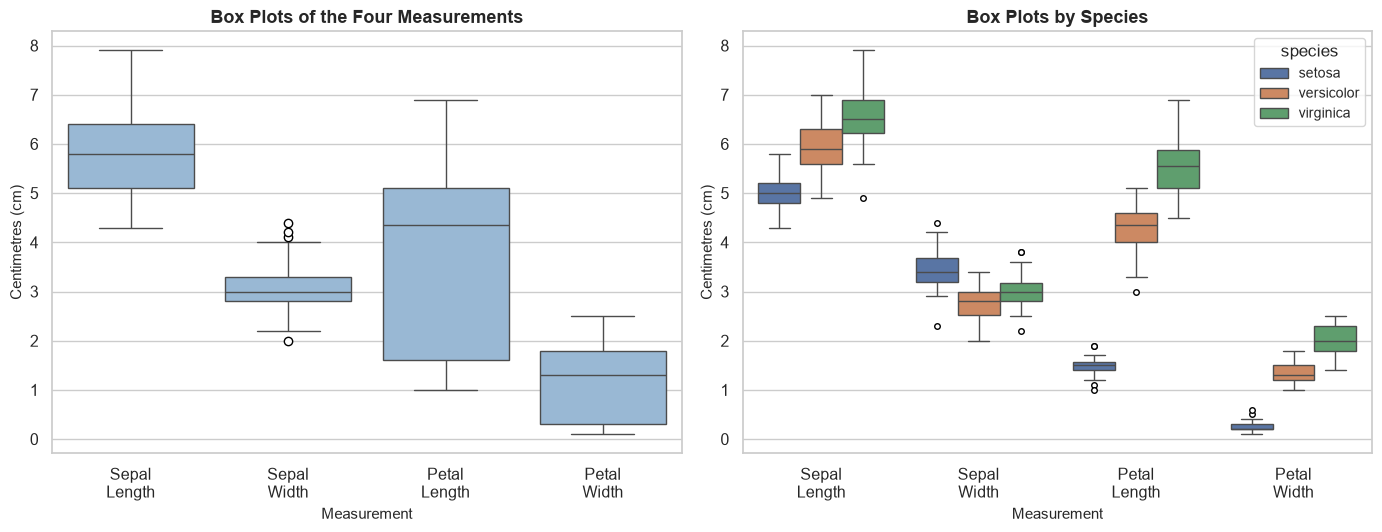

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.boxplot(data=df[FEATURES], color="#8FB8DE", ax=axes[0],
            flierprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"})
axes[0].set_title("Box Plots of the Four Measurements")
axes[0].set_xlabel("Measurement")
axes[0].set_ylabel("Centimetres (cm)")
axes[0].set_xticks(range(len(FEATURES)))
axes[0].set_xticklabels([da.nice_name(c).replace(" ", "\n") for c in FEATURES])

long_df = df.melt(id_vars="species", value_vars=FEATURES, var_name="measurement", value_name="cm")
sns.boxplot(data=long_df, x="measurement", y="cm", hue="species", ax=axes[1],
            flierprops={"marker": "o", "markersize": 4, "markerfacecolor": "white", "markeredgecolor": "black"})
axes[1].set_title("Box Plots by Species")
axes[1].set_xlabel("Measurement")
axes[1].set_ylabel("Centimetres (cm)")
axes[1].set_xticks(range(len(FEATURES)))
axes[1].set_xticklabels([da.nice_name(c).replace(" ", "\n") for c in FEATURES])
plt.tight_layout()
fig.savefig(IMAGES_DIR / "iris_box_plot.png", bbox_inches="tight", facecolor="white")
plt.show()

In [19]:
# The flowers flagged as potential outliers
da.get_outlier_rows(df, "sepal_width")

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


### Observation
* Only **sepal width** contains potential outliers: **4 of 150 flowers (about 2.7 %)**, three
  *setosa* flowers with unusually wide sepals (4.1, 4.2 and 4.4 cm) and one *versicolor* flower with
  an unusually narrow sepal (2.0 cm).
* Sepal length, petal length and petal width have **no** potential outliers, even though petal length
  and petal width are not bell-shaped - the two-cluster structure is spread out, not extreme.
* These values are plausible flower measurements and are **not** incorrect data: they are unusual
  compared with all 150 flowers, not impossible. All rows are kept.
* The right-hand plot compares each flower only with the other flowers of *its own species*, so it
  marks a few additional points (for example some small *setosa* petal measurements). Those are unusual
  within their species, not within the whole dataset, which is why the overall summary above counts
  only 4 flowers.

## 11. Comparison of Species

In [20]:
display(df.groupby("species")[FEATURES].mean().round(2))
display(df.groupby("species")[FEATURES].agg(["min", "max"]).round(1))

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


sepal_length      sepal_width      petal_length      petal_width  \
                    min  max         min  max          min  max         min   
species                                                                       
setosa              4.3  5.8         2.3  4.4          1.0  1.9         0.1   
versicolor          4.9  7.0         2.0  3.4          3.0  5.1         1.0   
virginica           4.9  7.9         2.2  3.8          4.5  6.9         1.4   

                 
            max  
species          
setosa      0.6  
versicolor  1.8  
virginica   2.5

### Observation
* Average **petal length** is 1.46 cm (*setosa*), 4.26 cm (*versicolor*) and 5.55 cm (*virginica*);
  average petal width is 0.25, 1.33 and 2.03 cm. The species are ordered
  setosa < versicolor < virginica for petal length, petal width and sepal length.
* **Setosa** has the *widest* sepals on average (3.43 cm) but the shortest sepals (5.01 cm) and by far the
  smallest petals.
* The petal-length ranges show how well the species can be told apart: setosa 1.0-1.9 cm,
  versicolor 3.0-5.1 cm, virginica 4.5-6.9 cm. Setosa does not overlap with the other two; versicolor
  and virginica overlap between 4.5 and 5.1 cm.

## 12. Key Insights

1. The dataset is complete: 150 flowers, no missing values, 50 flowers per species.
2. There is exactly one duplicated row (two *virginica* flowers); it was kept because two different
   flowers can share the same measurements at 0.1 cm precision.
3. Sepal width is roughly bell-shaped and sepal length is broad and flat-topped, while petal length and
   petal width form **two clusters** (small and large petals).
4. The two petal measurements are almost perfectly linearly related (r = 0.963), and sepal length is
   strongly related to both petal measurements (0.872 and 0.818).
5. Sepal width is the odd one out: it is weakly to moderately **negatively** correlated with the
   other measurements (-0.118, -0.366 and -0.428).
6. The small-petal cluster is exactly the *setosa* species: the largest setosa petal length (1.9 cm) is
   far below the smallest versicolor petal length (3.0 cm).
7. *Versicolor* and *virginica* overlap in petal length (4.5-5.1 cm), so they are harder to separate
   than setosa is.
8. The overall petal correlation (0.963) is much higher than within setosa (0.332) or virginica (0.322):
   a big part of it comes from differences between the species.
9. Only sepal width has potential outliers (4 flowers, 2.7 %); they are plausible measurements and were kept.
10. Petal measurements describe the species better than sepal measurements, whose species distributions
    overlap more.

## 13. Conclusion
The Iris dataset is small, clean and well balanced. The exploration showed that the petal
measurements are the most informative for distinguishing the species, that the strong overall
correlations partly reflect species differences, and that there are very few outliers. As with the
student data, all findings are descriptive; no model was trained in this task.